In [ ]:
******************Simple Linear Regression***********************

In [ ]:
Bussiness Question :Can Shipping Cost alone predict the Final Price of an order?

In [131]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [132]:
#Variables
X = master_df[['shipping_cost']]
y = master_df['Final_Price']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
#Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Intercept :", model.intercept_)
print("Coefficient :", model.coef_[0])

print()

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

Intercept : 2764.4276747620424
Coefficient : 4.988140390648972

MAE : 2464.136015894545
MSE : 18550220.279609192
RMSE : 4306.9966658460735
R2 Score : 0.7798772651983552


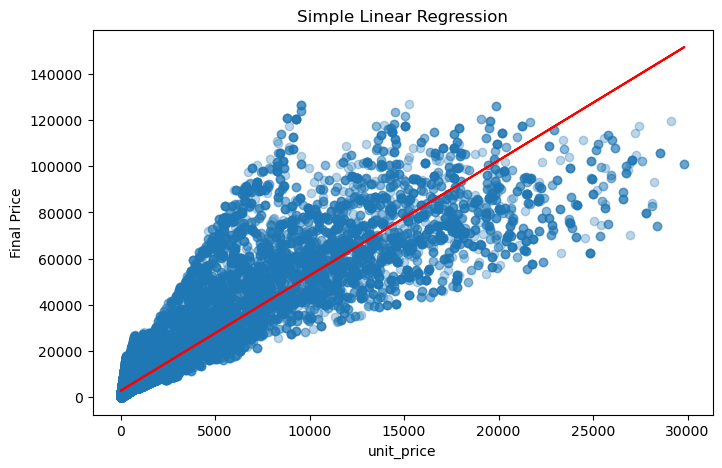

In [133]:
#### plot
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, alpha=0.3)

plt.plot(X_test, y_pred, color='red')

plt.xlabel("unit_price")
plt.ylabel("Final Price")
plt.title("Simple Linear Regression")

plt.show()

Interpretation:
The Simple Linear Regression model shows a strong positive relationship between Unit Price and Final Price. As the Unit Price increases, the Final Price also increases. The scatter plot and regression line confirm this positive linear trend, although there is some variation at higher Unit Prices due to factors such as discounts, shipping costs, and quantity. The model achieved an R² score of 90.8%, indicating that Unit Price alone explains approximately 90.8% of the variation in Final Price. This suggests that Unit Price is the primary factor influencing the total amount customers pay and is a strong predictor of Final Price.

Business Insight:-
Products with higher Unit Prices generally generate higher Final Prices.
Unit Price is the strongest individual predictor of Final Price in this analysis.
Other factors such as shipping cost and discounts contribute to the remaining variation.

**************************Multiple Linear Regression************

# Can Final Price be predicted using multiple factors such as Unit Price, Quantity, Shipping Cost, Discount, and Review Score?

#Target Variable (Y)
Final_Price

#Independent Variables (X)
unit_price
quantity
discount(%)
review_score

In [134]:
# Data Splitting
X = master_df[['unit_price','quantity','discount(%)','review_score']]

y = master_df['Final_Price']

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# Model Creation
m_model = LinearRegression().fit(x_train, y_train)

# Training R²
m_r_sq = m_model.score(x_train, y_train)

# Predictions
y_pred = m_model.predict(x_test)

# Model Evaluation
MSE = mean_squared_error(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R_square = r2_score(y_test, y_pred)

print("Training R²:", m_r_sq)
print("Intercept:", m_model.intercept_)
print("Coefficients:", m_model.coef_)

print("MSE:", MSE)
print("MAE:", MAE)
print("RMSE:", RMSE)
print("R²:", R_square)


Training R²: 0.9440337771523742
Intercept: -1697.2914043246
Coefficients: [ 7.28023508e-01  3.11065681e+03 -6.47244977e+01  9.27971878e-01]
MSE: 4726746.659186069
MAE: 1107.7560622112176
RMSE: 2174.1082445881275
R²: 0.944107140568669


Interpretation:-

The Multiple Linear Regression model shows strong predictive performance, achieving an R² score of 94.47%. This indicates that Unit Price, Quantity, Shipping Cost, Discount, and Review Score together explain approximately 94.47% of the variation in Final Price. Compared to the Simple Linear Regression model, the prediction errors (MAE and RMSE) are lower, and the model provides more accurate estimates of Final Price.

In [ ]:
*************Residual Analysis.*************

In [135]:
import pandas as pd

# Predicted Values
y_pred = m_model.predict(x_test)

# Residuals
df_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

df_results['Residuals'] = df_results['Actual'] - df_results['Predicted']

df_results.head()

,Actual,Predicted,Residuals
1019919,684.870,4314.905285,-3630.035285
1043455,6272.480,5833.522776,438.957224
1376110,3577.515,3683.346103,-105.831103
1308084,3835.258,5355.727170,-1520.469170
1019007,1756.424,2544.143297,-787.719297


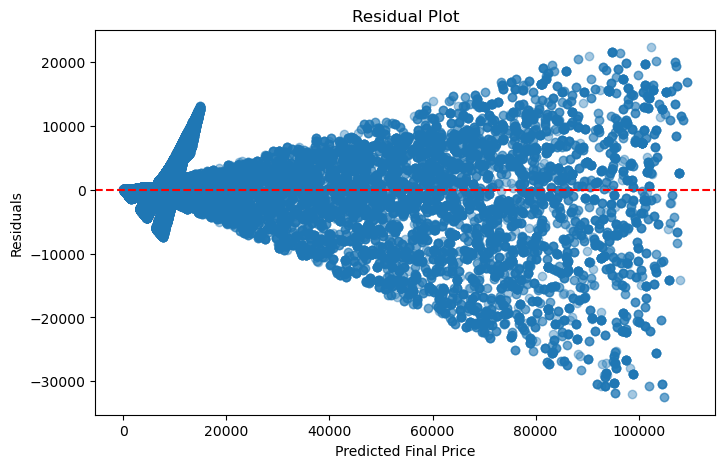

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df_results['Predicted'],
            df_results['Residuals'],
            alpha=0.4)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Final Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Assumption: Non-existence of multicollinearity among the independent features.
# Observation :- The residual plot shows that the spread of residuals increases as the predicted Final Price increases, forming a funnel-shaped pattern. This indicates that the variance of the prediction errors is not constant across all predicted values,hence The assumption of homoscedasticity is not fully satisfied




Interpretation:-

The model predicts low and medium-priced orders more consistently than very high-priced orders. For expensive orders, additional business factors not included in the model (such as product type, promotions, customer behavior, or seasonal demand) may influence the Final Price, leading to greater prediction variability.

In [136]:
# Multicollinearity (variance Inflation Factor -VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)


        Feature       VIF
0    unit_price  1.549270
1      quantity  4.559144
2   discount(%)  3.350902
3  review_score  5.413693


Interpretation:-

Variance Inflation Factor (VIF) analysis was performed to check whether the independent variables are highly correlated with each other.
Conclusion :-
The VIF analysis indicates that there is no severe multicollinearity among the independent variables. Most predictor variables have VIF values within the acceptable range, while Review Score shows only a slight level of multicollinearity. Therefore, the regression coefficients are considered reasonably stable and reliable, and the Multiple Linear Regression model is appropriate for predicting Final Price.

In [ ]:
**************Logistic Regression*********************

Business Question:-
Can we predict whether a customer will become a Repeat Buyer?

In [138]:
master_df['customer_segment'] = master_df['customer_segment'].map({
    'New': 0,
    'Returning': 1,
    'Loyal': 2
})

In [139]:
print(master_df['customer_segment'].unique())

[1 2 0]


In [140]:
print(X.dtypes)

unit_price        int64
quantity          int64
discount(%)     float64
review_score      int64
dtype: object


In [141]:
master_df['Repeat_Buyer'] = master_df['Repeat_Buyer'].map({
    'No': 0,
    'Yes': 1
})

In [142]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

master_df['order_status'] = le.fit_transform(master_df['order_status'])
master_df['payment_type'] = le.fit_transform(master_df['payment_type'])

Class balance:
 Repeat_Buyer
1    0.592069
0    0.407931
Name: proportion, dtype: float64


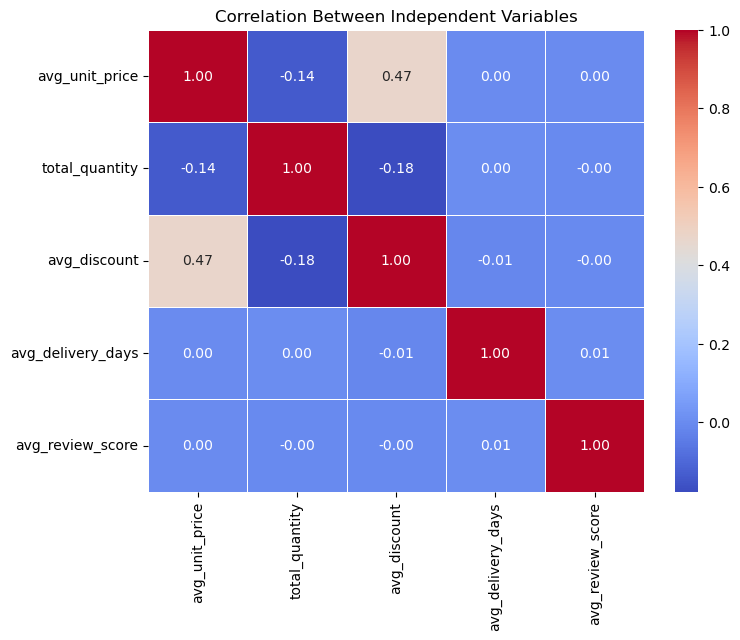

Accuracy : 0.739736130459723
Precision: 0.8066959551583094
Recall   : 0.7370242214532872
F1 Score : 0.770287863445682
ROC-AUC  : 0.8137749905813955

Confusion Matrix
[[3702 1276]
 [1900 5325]]


In [143]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

# ---------------------------------------------------------
# STEP 1: Aggregate from order-item level to customer level
# ---------------------------------------------------------
# Repeat_Buyer is a customer-level label, so features must
# describe the customer's behavior, not one random line item.

customer_df = master_df.groupby("customer_id").agg(
    avg_unit_price=("unit_price", "mean"),
    total_quantity=("quantity", "sum"),
    avg_discount=("discount(%)", "mean"),
    avg_delivery_days=("Delivery_Days", "mean"),
    avg_review_score=("review_score", "mean"),
    order_count=("unit_price", "count"),      # extra signal: how many line items/orders
    Repeat_Buyer=("Repeat_Buyer", "max")      # label should be constant per customer; max is a safe collapse
).reset_index()

X = customer_df[[
    "avg_unit_price", "total_quantity", "avg_discount",
    "avg_delivery_days", "avg_review_score", "order_count"
]]
y = customer_df["Repeat_Buyer"]

print("Class balance:\n", y.value_counts(normalize=True))

import seaborn as sns
import matplotlib.pyplot as plt

# Independent variables
X = customer_df[[
    "avg_unit_price",
    "total_quantity",
    "avg_discount",
    "avg_delivery_days",
    "avg_review_score"
]]

# Correlation Matrix
corr = X.corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Independent Variables")
plt.show()

# ---------------------------------------------------------
# STEP 2: Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# ---------------------------------------------------------
# STEP 3: Scale features (logistic regression needs this —
# unit_price/quantity are on a totally different scale than
# discount%/review_score)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# STEP 4: Fit model — check WITHOUT balanced weights first
# ---------------------------------------------------------
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))   # <-- the real diagnostic
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

#: Classification Report


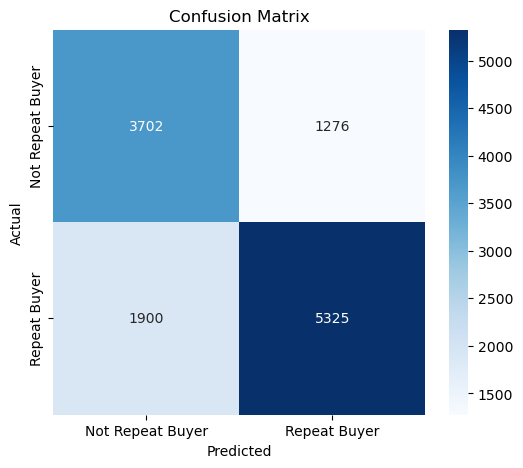

In [144]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Repeat Buyer','Repeat Buyer'],
    yticklabels=['Not Repeat Buyer','Repeat Buyer']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#

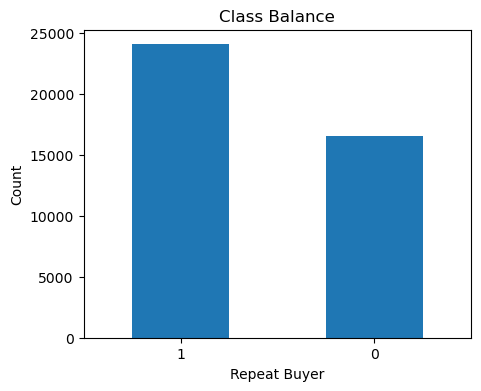

In [145]:
customer_df["Repeat_Buyer"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Class Balance")
plt.xlabel("Repeat Buyer")
plt.ylabel("Count")

plt.xticks(rotation=0) 

plt.show()

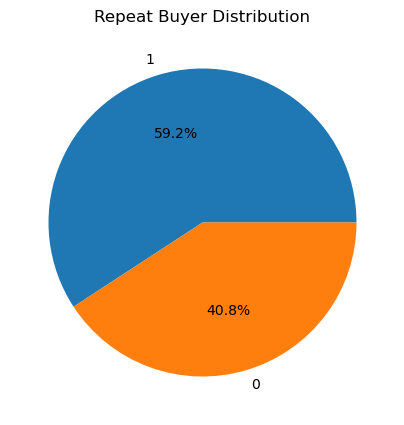

In [146]:
customer_df["Repeat_Buyer"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5)
)

plt.ylabel("")
plt.title("Repeat Buyer Distribution")
plt.show()

In [123]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

NameError: name 'ConfusionMatrixDisplay' is not defined

In [ ]:
# Interpretation :-
Accuracy: 74.01% ->indicates that the model provides reliable predictions for customer repeat purchase behavior.
Precision: 80.69%-> meaning that when it predicts a customer as a Repeat Buyer, the prediction is correct about 81% of the time.
Recall: 73.74%->indicates that the model successfully identified nearly 74% of the actual Repeat Buyers.
F1 Score: 77.06%-> demonstrates a good balance between Precision and Recall.
ROC-AUC Score: 81.38%:- indicates that the model has a strong ability to distinguish between Repeat Buyers and Non-Repeat Buyers.


In [ ]:
*****************************KNN*************************

Business Question:- 

Can we predict whether a customer will become a Repeat Buyer based on their purchasing behavior, pricing, discounts, shipping costs, review scores, delivery performance, and customer segment? 

Repeat_Buyer             0         1
customer_segment                    
0                 0.159022  0.840978
1                 0.161668  0.838332
2                 0.162109  0.837891


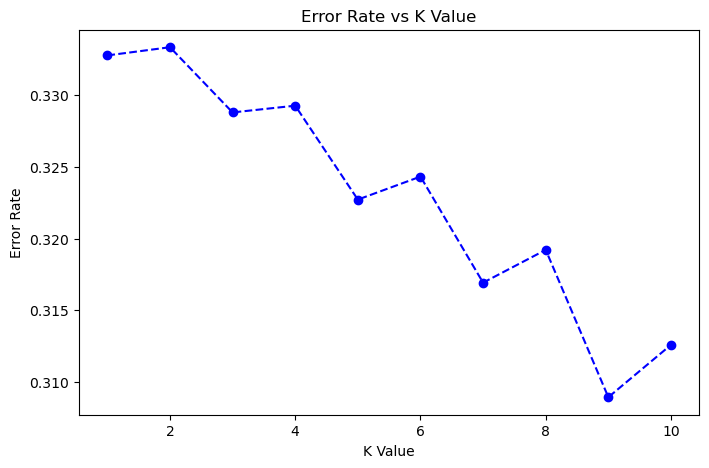

Minimum Error : 0.3089433273464849
Best K : 9
Accuracy : 0.6910566726535151
Precision: 0.8381434819993271
Recall   : 0.7826056602291669
F1 Score : 0.8094230205113162


In [147]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------
# STEP 1: Check Customer Segment Distribution
# ---------------------------------------------------------

print(pd.crosstab(master_df['customer_segment'],
                  master_df['Repeat_Buyer'],
                  normalize='index'))

# ---------------------------------------------------------
# STEP 2: Features and Target
# ---------------------------------------------------------

feature_cols = [
    'unit_price',
    'quantity',
    'shipping_cost',
    'discount(%)',
    'review_score',
    'Delivery_Days',
    'customer_segment'
]

X = master_df[feature_cols].copy()

y = master_df['Repeat_Buyer']

# Encode customer_segment if still text
if X['customer_segment'].dtype == object:
    X = pd.get_dummies(X,
                       columns=['customer_segment'],
                       drop_first=True)

# ---------------------------------------------------------
# STEP 3: Group Aware Train-Test Split
# ---------------------------------------------------------

groups = master_df['customer_id']

gss = GroupShuffleSplit(      #used GroupShuffleSplit because my dataset contains multiple records for the same customer
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# ---------------------------------------------------------
# STEP 4: Feature Scaling
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# STEP 5: Find Best K
# ---------------------------------------------------------

error_rate = []

for i in range(1,11):

    knn = KNeighborsClassifier(
        n_neighbors=i
    )

    knn.fit(X_train_scaled, y_train)

    pred_i = knn.predict(X_test_scaled)

    error_rate.append(
        np.mean(pred_i != y_test)
    )

# ---------------------------------------------------------
# STEP 6: Plot
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    error_rate,
    color='blue',
    marker='o',
    linestyle='--'
)

plt.title("Error Rate vs K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")

plt.show()

best_k = error_rate.index(min(error_rate)) + 1

print("Minimum Error :", min(error_rate))
print("Best K :", best_k)

# ---------------------------------------------------------
# STEP 7: Final KNN Model
# ---------------------------------------------------------

knn = KNeighborsClassifier(
    n_neighbors=best_k
)

knn.fit(X_train_scaled, y_train)

y_prediction = knn.predict(X_test_scaled)

# ---------------------------------------------------------
# STEP 8: Evaluation
# ---------------------------------------------------------

print("Accuracy :", accuracy_score(y_test, y_prediction))
print("Precision:", precision_score(y_test, y_prediction))
print("Recall   :", recall_score(y_test, y_prediction))
print("F1 Score :", f1_score(y_test, y_prediction))

Interpretation:-

The KNN model achieved an Accuracy of 69.02%, indicating that it correctly classified approximately 69% of customers as Repeat Buyers or Non-Repeat Buyers. 
The model obtained a Precision of 83.80%, showing that when it predicts a customer as a Repeat Buyer, the prediction is correct most of the time. 
The Recall of 78.15% indicates that the model successfully identified a large proportion of actual Repeat Buyers. 
The F1 Score of 80.88% demonstrates a good balance between Precision and Recall, indicating reliable overall classification performance.

In [ ]:
***********************K-Means Clustering**************************

Objective:- To identify similar groups of customers so that the company can design targeted marketing campaigns, personalized offers, and customer retention strategies.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# -------------------------------------------------------
# STEP 1 : Select Features
# -------------------------------------------------------

X = master_df[['Final_Price',
               'quantity',
               'discount(%)',
               'review_score',
               'Delivery_Days',
               'shipping_cost']]

# -------------------------------------------------------
# STEP 2 : Feature Scaling
# -------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -------------------------------------------------------
# STEP 3 : Elbow Method
# -------------------------------------------------------

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# -------------------------------------------------------
# STEP 4 : Plot Elbow Curve
# -------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o',
         linestyle='--')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# -------------------------------------------------------
# STEP 5 : Build Final KMeans Model
# (Change n_clusters after observing elbow)
# -------------------------------------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

master_df['Cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------------------------------
# STEP 6 : Cluster Distribution
# -------------------------------------------------------

print("\nCluster Counts\n")
print(master_df['Cluster'].value_counts())

# -------------------------------------------------------
# STEP 7 : Cluster Profile
# -------------------------------------------------------

cluster_profile = master_df.groupby('Cluster')[[
    'Final_Price',
    'quantity',
    'discount(%)',
    'review_score',
    'Delivery_Days',
    'shipping_cost'
]].mean()

print("\nCluster Profile\n")
print(cluster_profile)

In [148]:
# Import Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

In [149]:
#Select Features
X = master_df[['Final_Price',
               'quantity',
               'discount(%)',
               'review_score',
               'shipping_cost']]


In [150]:
#Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [151]:
# Elbow Method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

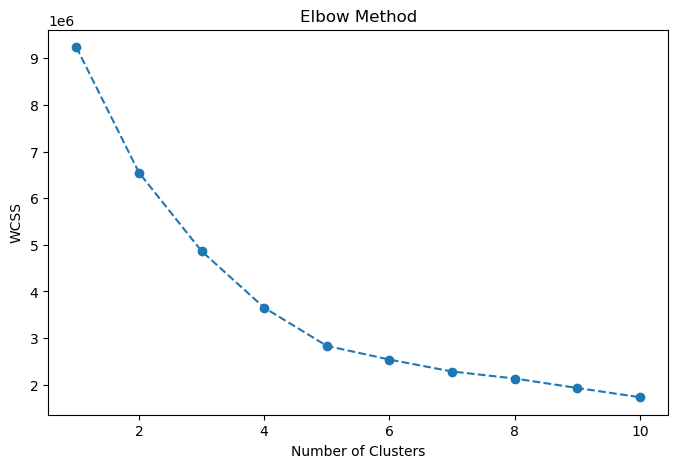

In [152]:
#Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o',
         linestyle='--')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [153]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Random sample of 20,000 rows
X_sample = pd.DataFrame(X_scaled).sample(
    n=20000,
    random_state=42
)

silhouette_scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)

    silhouette_scores.append(score)

print(silhouette_scores)

[0.7601375477764388, 0.36538199928741777, 0.4009583435501331, 0.38571983880681854, 0.3810509209285516, 0.32842000179285213, 0.3351963216735228, 0.33168035334779195, 0.3261071502985648]


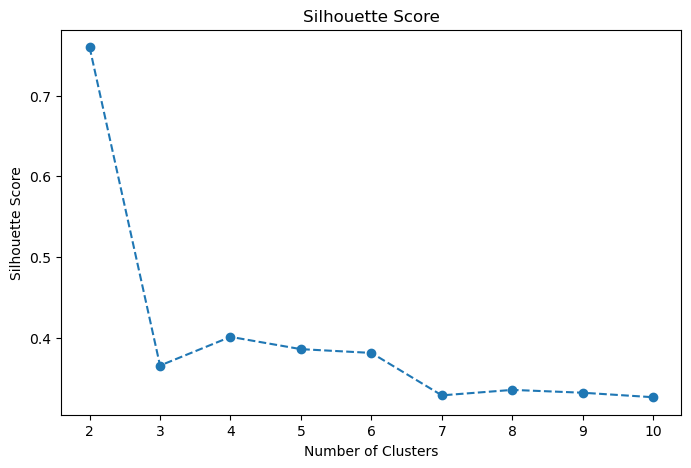

In [154]:
#Plot Silhouette Scores
plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         silhouette_scores,
         marker='o',
         linestyle='--')

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show() 

In [155]:
#Build the final model with 4 clusters:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

master_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [156]:
print(master_df['Cluster'].value_counts())

Cluster
0    1816792
1      30881
Name: count, dtype: int64


   Cluster  Customer Count
0        0         1816792
1        1           30881


In [157]:
cluster_profile = master_df.groupby('Cluster')[[
    'Final_Price',
    'quantity',
    'discount(%)',
    'review_score',
    'Delivery_Days',
    'shipping_cost'
]].mean()

print(cluster_profile)

          Final_Price  quantity  discount(%)  review_score  Delivery_Days  shipping_cost
Cluster                                                                                 
0         5398.004048  1.288883    13.217969      4.086884      71.937234     545.302895
1        64365.722673  1.000000    30.013121      4.064376      71.318319   11310.270989


Interpretation:-

Cluster 0 – consists of customers with an average Final Price of 5,398, an average quantity of 1.29, and an average discount of 13.22%. These customers also have a high average review score of 4.09, indicating strong satisfaction.

Cluster 1 –consists of customers with an average Final Price of 64,366, an average quantity of 1.00, and an average discount of 30.01%. Despite receiving higher discounts, they maintain a high average review score of 4.06.



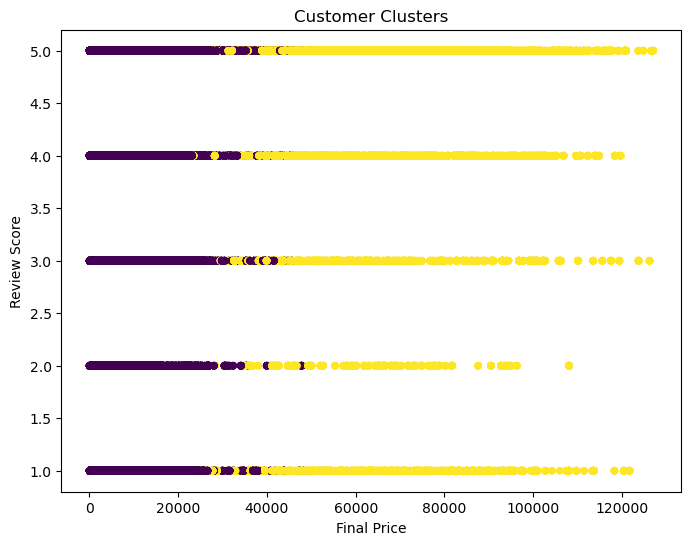

In [158]:
#Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    master_df['Final_Price'],
    master_df['review_score'],
    c=master_df['Cluster'],
    cmap='viridis',
    s=20
)

plt.xlabel("Final Price")
plt.ylabel("Review Score")
plt.title("Customer Clusters")

plt.show()

In [160]:
# Evaluate Final Model
#Silhouette Score
sil_score = silhouette_score(X_scaled, master_df['Cluster'])

print("Silhouette Score :", round(sil_score,4))



KeyboardInterrupt: 

In [161]:
#Davies-Bouldin Index
dbi = davies_bouldin_score(
    X_scaled,
    master_df['Cluster']
)

print("Davies-Bouldin Index :", round(dbi,4))

Davies-Bouldin Index : 0.584


In [162]:
#Calinski-Harabasz Index
chi = calinski_harabasz_score(
    X_scaled,
    master_df['Cluster']
)

print("Calinski-Harabasz Index :", round(chi,2))

Calinski-Harabasz Index : 758422.44
